#  House Price Prediction over train.csv Kaggle Dataset

Step 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Step 2: Load the training dataset

In [ ]:
try:
    df = pd.read_csv('/train.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'train.csv' not found. Please upload the Kaggle dataset to Google Colab.")
    # Generating dummy data for demonstration if file is missing
    np.random.seed(42)
    dummy_size = 500
    dummy_area = np.random.normal(1500, 500, dummy_size).round()
    dummy_rooms = (dummy_area / 250 + np.random.randint(1, 4, dummy_size)).astype(int)
    dummy_price = (dummy_area * 120 + dummy_rooms * 15000 + np.random.normal(0, 20000, dummy_size)).round()
    df = pd.DataFrame({'GrLivArea': dummy_area, 'TotRmsAbvGrd': dummy_rooms, 'SalePrice': dummy_price})

Dataset loaded successfully!


Step 3: Data Cleaning and preprocessing

In [ ]:
# Select essential columns
columns_to_keep = ['GrLivArea', 'TotRmsAbvGrd', 'SalePrice']
df = df[columns_to_keep]

# Handle Missing Values
print("\nMissing values before cleaning:\n", df.isnull().sum())
df = df.dropna()


Missing values before cleaning:
 GrLivArea       0
TotRmsAbvGrd    0
SalePrice       0
dtype: int64


Step 4 : Initialize X & y

In [ ]:
# Features and Target
X = df[['GrLivArea', 'TotRmsAbvGrd']]
y = df['SalePrice']


Step 5: Train Test Split

In [ ]:
# Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining set size: {X_train.shape[0]} | Testing set size: {X_test.shape[0]}")


Training set size: 1168 | Testing set size: 292


Step 6: Initialize Linear Regression model

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([129905.087899  , 296109.21043476, 132443.11773013, 194761.00917541,
       196814.19043742,  98973.71614743, 222526.01491421, 169548.88358122,
        98973.71614743, 154526.00309528, 179480.85409142, 113776.44781905,
       108814.17514233, 179124.64282132, 197912.52487468, 122632.35936222,
       201548.88914307, 137905.08928947, 123117.20793134, 172336.76285366,
       204222.98142997, 193177.82616903, 171973.12642682, 128678.11616272,
       173905.09554655, 153170.39405997, 162874.79059909, 119950.84191857,
       187488.28063863, 171715.85182877, 159594.63760079, 233677.53200395,
       330192.0978856 , 130617.51043919, 183980.55366926, 145534.02909635,
       223851.92332255, 219374.49921494, 276359.05639991, 122132.66047961,
       142995.99926522, 241435.10910985, 122988.57063231, 233192.68343483,
       127594.63203894, 253556.32333783, 118382.50922568, 116208.11582139,
       249207.53652925, 177791.30925625, 120208.11651663, 197776.46241891,
       173284.18452166, 3

Step 7: Evaluation metrics

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n================ MODEL METRICS ================")
print(f"Mean Squared Error (MSE) : {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R² (Coefficient of Determination) Score: {r2:.4f}")

# Show Actual vs Predicted Sample
comparison_df = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred}).reset_index(drop=True)
print("\nSample Predictions:")
print(comparison_df.head(5))


================ MODEL METRICS ================
Mean Squared Error (MSE) : 3347874783.82
Root Mean Squared Error (RMSE): $57860.82
R² (Coefficient of Determination) Score: 0.5635

Sample Predictions:
   Actual Price  Predicted Price
0        154500    129905.087899
1        325000    296109.210435
2        115000    132443.117730
3        159000    194761.009175
4        315500    196814.190437


Step 7: Visualization

Text(0, 0.5, 'House Price ($)')

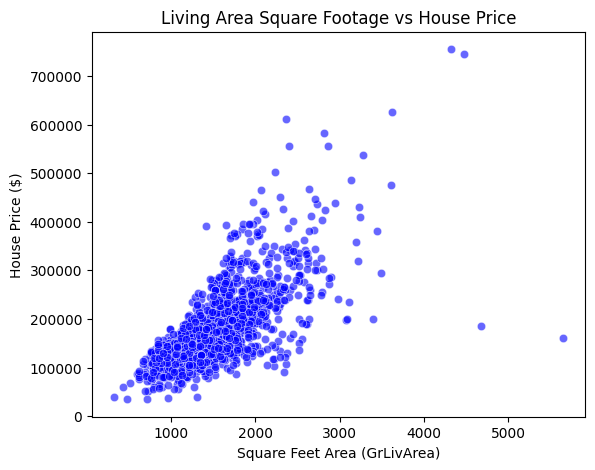

In [ ]:

plt.figure(figsize=(14, 5))

# Graph 1: Area vs Price
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', alpha=0.6, color='blue')
plt.title('Living Area Square Footage vs House Price')
plt.xlabel('Square Feet Area (GrLivArea)')
plt.ylabel('House Price ($)')


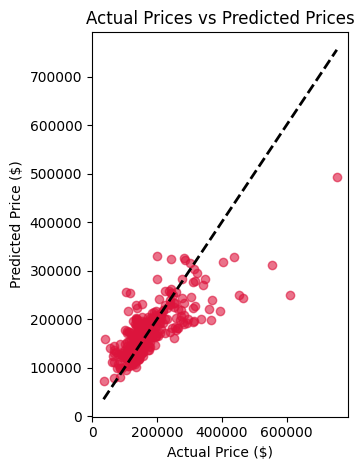

In [ ]:
# Graph 2: Actual vs Predicted prices
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.6, color='crimson')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual Prices vs Predicted Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')

plt.tight_layout()
plt.show()

Step 8 :  Final Output (Prediction for Custom Input)

In [ ]:
print("\n================ CUSTOM PREDICTION ================")
def predict_custom_house_price(area, rooms):
    custom_input = pd.DataFrame([[area, rooms]], columns=['GrLivArea', 'TotRmsAbvGrd'])
    predicted_price = model.predict(custom_input)[0]
    print(f"🏠 Input Area: {area} sq ft | Input Rooms: {rooms}")
    print(f"💰 Predicted House Price: ${predicted_price:,.2f}")
    return predicted_price

predict_custom_house_price(area=2000, rooms=4)


================ CUSTOM PREDICTION ================
🏠 Input Area: 2000 sq ft | Input Rooms: 4
💰 Predicted House Price: $257,647.84


np.float64(257647.83554835763)